In [1]:
import os
os.chdir("../..")

In [2]:
import torch
from torch.utils.data import Dataset,DataLoader
import pickle
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

In [3]:
class MLROD_dataset(Dataset):
  def __init__(self,path):
    """
    path is a string containing the path to the pkl dataset
    """
    super().__init__()   
    self.y, self.X = pickle.load(open(path, 'rb'))
    self.y = list(self.y) #y is a list with containing the name of the chemical corresponding to X
    self.X = list(self.X) #X is a list with each element of the list containing a 1024 time series data    

    #To remove the Unknown samples from the dataset
    i = 0
    while i<len(self.y):
      if self.y[i]==15:
        self.y.pop(i)
        self.X.pop(i)
      
      else:
        i+=1

  def __len__(self):
    return len(self.y)

  def __getitem__(self,index):
    data = torch.Tensor(self.X[index]) #of shape (1,1024)
    data = (data-data.min())/(data.max()-data.min())
    label = self.y[index]
    return data,label

In [4]:
train_set = MLROD_dataset("datasets/MLROD/MLROD_train.pkl")
test_set = MLROD_dataset("datasets/MLROD/MLROD_test.pkl")

print(f"The number of elements in the train set is {len(train_set)}")
print(f"The number of elements in the test set is {len(test_set)}")

test_set_granite_0 = MLROD_dataset("datasets/MLROD/MLROD_test_granite_0.pkl")
test_set_granite_50 = MLROD_dataset("datasets/MLROD/MLROD_test_granite_50.pkl")
test_set_gabbro_0 = MLROD_dataset("datasets/MLROD/MLROD_test_gabbro_0.pkl")
test_set_gabbro_50 = MLROD_dataset("datasets/MLROD/MLROD_test_gabbro_50.pkl")
print(f"The number of elements in the test set is {len(test_set_granite_0)}")
print(f"The number of elements in the test set is {len(test_set_granite_50)}")
print(f"The number of elements in the test set is {len(test_set_gabbro_0)}")
print(f"The number of elements in the test set is {len(test_set_gabbro_50)}")

noisy = test_set_granite_50+test_set_gabbro_50
clean = test_set_granite_0+test_set_gabbro_0
x = np.linspace(141.022,1100.46,1024)

The number of elements in the train set is 90341
The number of elements in the test set is 34903
The number of elements in the test set is 11028
The number of elements in the test set is 5183
The number of elements in the test set is 8952
The number of elements in the test set is 9740


3 3 3
1 1 1
2 2 2


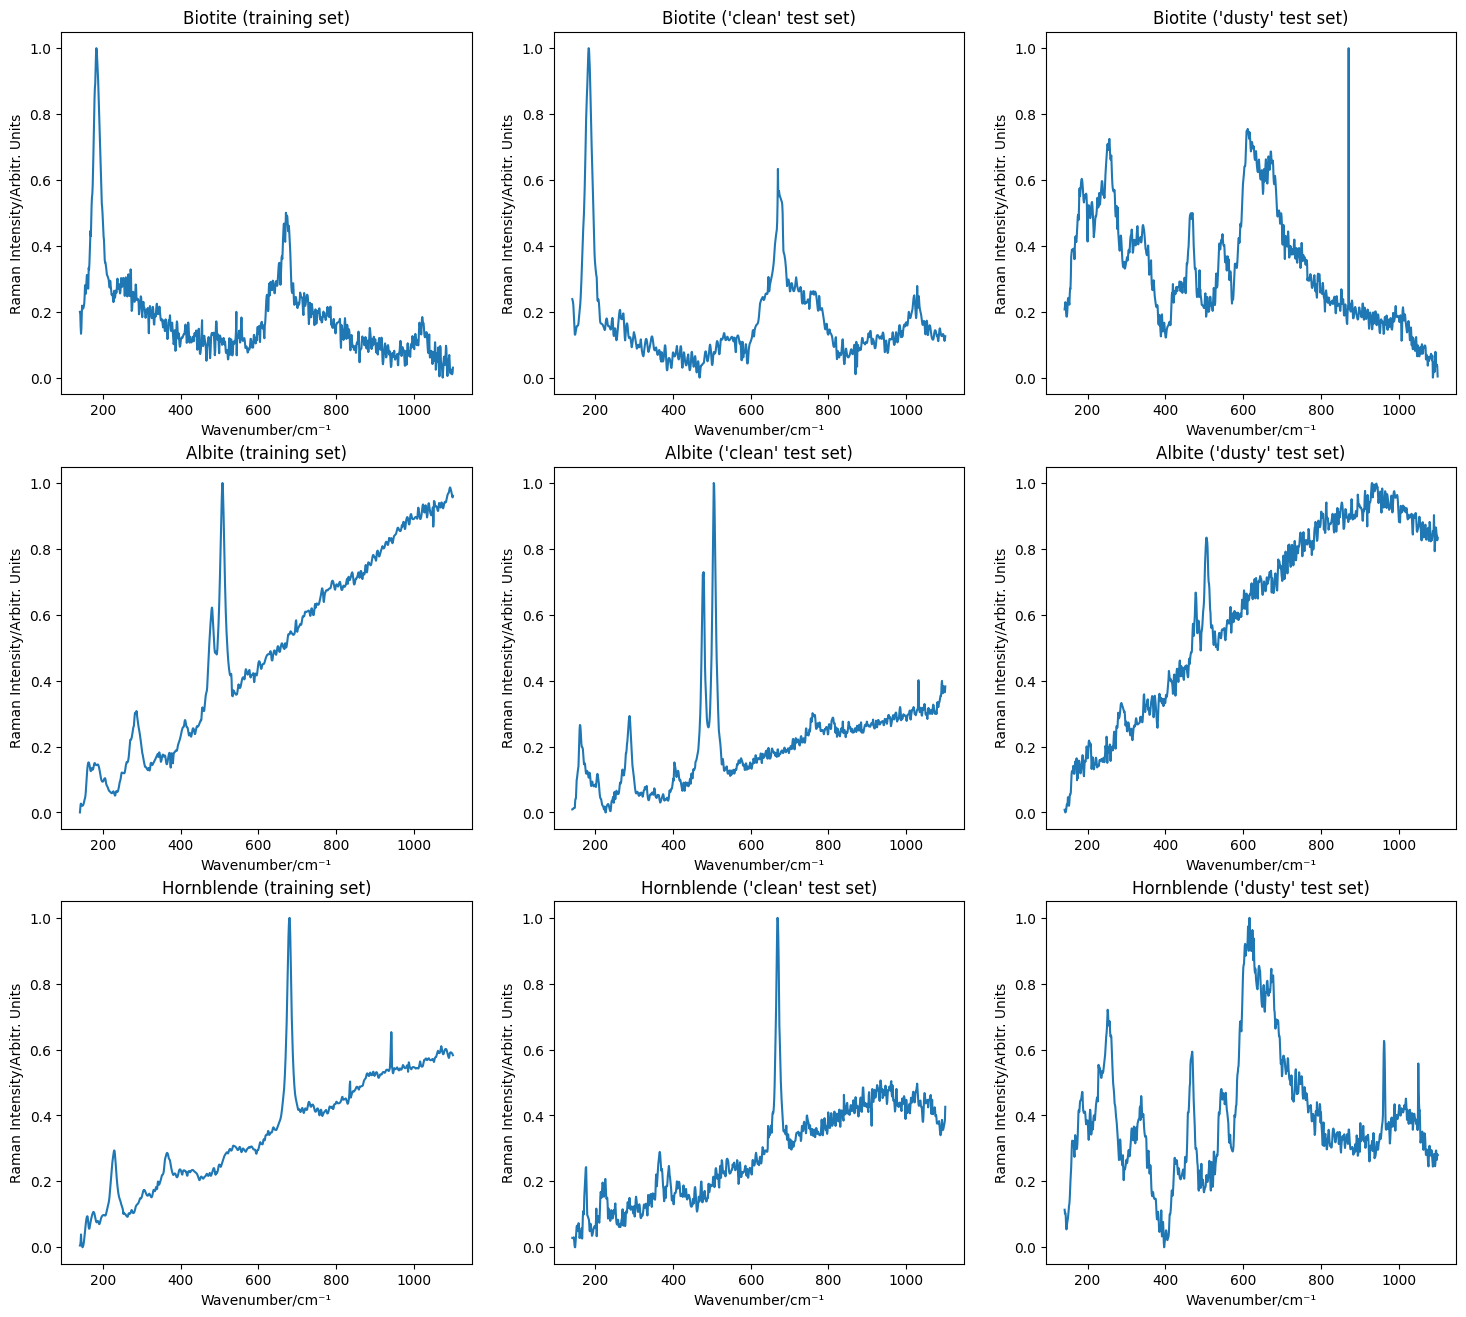

In [7]:
fig,ax = plt.subplots(nrows=3,ncols=3,figsize=(18,16))

#For biotite
ax[0,0].plot(x,train_set[0][0].squeeze())
ax[0,0].set_title("Biotite (training set)")
ax[0,0].set_xlabel("Wavenumber/cm⁻¹")
ax[0,0].set_ylabel("Raman Intensity/Arbitr. Units")

ax[0,1].plot(x,clean[8644][0].squeeze())
ax[0,1].set_title("Biotite ('clean' test set)")
ax[0,1].set_xlabel("Wavenumber/cm⁻¹")
ax[0,1].set_ylabel("Raman Intensity/Arbitr. Units")
        

ax[0,2].plot(x,noisy[50][0].squeeze())
ax[0,2].set_title("Biotite ('dusty' test set)")
ax[0,2].set_xlabel("Wavenumber/cm⁻¹")
ax[0,2].set_ylabel("Raman Intensity/Arbitr. Units")

print(train_set[0][1],clean[8644][1],noisy[50][1])

#For Albite
ax[1,0].plot(x,train_set[1100][0].squeeze())
ax[1,0].set_title("Albite (training set)")
ax[1,0].set_xlabel("Wavenumber/cm⁻¹")
ax[1,0].set_ylabel("Raman Intensity/Arbitr. Units")

ax[1,1].plot(x,clean[1375][0].squeeze())
ax[1,1].set_title("Albite ('clean' test set)")
ax[1,1].set_xlabel("Wavenumber/cm⁻¹")
ax[1,1].set_ylabel("Raman Intensity/Arbitr. Units")
        

ax[1,2].plot(x,noisy[17][0].squeeze())
ax[1,2].set_title("Albite ('dusty' test set)")
ax[1,2].set_xlabel("Wavenumber/cm⁻¹")
ax[1,2].set_ylabel("Raman Intensity/Arbitr. Units")

print(train_set[1100][1],clean[1375][1],noisy[17][1])

#For Hornblende
ax[2,0].plot(x,train_set[26941][0].squeeze())
ax[2,0].set_title("Hornblende (training set)")
ax[2,0].set_xlabel("Wavenumber/cm⁻¹")
ax[2,0].set_ylabel("Raman Intensity/Arbitr. Units")

ax[2,1].plot(x,clean[2][0].squeeze())
ax[2,1].set_title("Hornblende ('clean' test set)")
ax[2,1].set_xlabel("Wavenumber/cm⁻¹")
ax[2,1].set_ylabel("Raman Intensity/Arbitr. Units")
        

ax[2,2].plot(x,noisy[201][0].squeeze())
ax[2,2].set_title("Hornblende ('dusty' test set)")
ax[2,2].set_xlabel("Wavenumber/cm⁻¹")
ax[2,2].set_ylabel("Raman Intensity/Arbitr. Units")

print(train_set[26941][1],clean[2][1],noisy[201][1])

plt.savefig("output.pdf")
